# Project 3
# Geology Forecast Challenge (Predicting rock type distributions from geological sensor data)

#### 1. Student name: S M AMIT HASAN
#### 1. Student ID: 25004146

#### 2. Student name: NITIN ARORA
#### 2. Student ID: 25005411

# Introduction

In this project, we explored a real-world dataset from a Kaggle competition called the Geology Forecast Challenge. The goal was to predict a specific target value related to geological data using machine learning models.

We started by understanding and cleaning the data, followed by trying different models to see which performed best. Our approach included using k-Nearest Neighbors (kNN), tree-based models like Random Forest, and linear models like Ridge Regression. We also focused on tuning these models to improve performance.

To gain deeper insights, we experimented with clustering to explore hidden patterns in the data. Along the way, we carefully handled feature selection, checked for data leakage, and evaluated our models using cross-validation. We tracked our Kaggle scores over time to see how our changes affected the results.

This notebook outlines the full machine learning workflow, including:
- Data loading and preprocessing
- Exploratory data analysis (EDA)
- Baseline and advanced modeling (starting with k-Nearest Neighbors)
- Feature analysis and selection
- Evaluation using cross-validation
- Submission of predictions to Kaggle

This project allows us to apply the techniques we’ve learned in class from exploratory data analysis to model evaluation, on a challenging, real-world dataset. It also gives us the chance to engage with the Kaggle community and benchmark our solutions against peers through a leaderboard. Ultimately, the project isn’t just about building accurate models, but also about understanding the data deeply, making thoughtful design choices, and learning from each step of the process.

Overall, this project helped us practice the end-to-end process of a data science workflow from data exploration and preprocessing to modeling and interpretation.

#### Problem Statement
Develop a machine learning model to predict the probability distribution of rock types from geological drilling sensor data. This is a classification problem where the output should match the submission format (probabilities per class), and the evaluation metric is log loss.

## List the key steps you took to perform EDA
1. Dataset Overview
2. Missing Value Analysis
3. Statistical Summary
4. Correlation Check
5. Distribution Plots
6. Feature Relationships
7. Boxplots and Outliers
8. Clustering analysis

## List and describe your kNN methodological design you used for experimental testing, benchmarking against a baseline, tuning, ensuring data leakage was not ocurring and how you effectively summarised and communicated all your results
In this project, we applied a well-structured and rigorous methodological design to develop and evaluate a k-Nearest Neighbors (kNN) model. The design covered all critical stages as below.
1. Experimental Testing
   - Train-Test Split
   - Feature Scaling
   - Baseline Comparison
2. Benchmarking
   - Training kNN models with varying k values and both uniform and distance weighting schemes
   - For each configuration, we used 5-fold cross-validation and computed Root Mean Squared Error (RMSE) as the primary metric
   - This approach allowed us to visualize model behavior over a range of hyperparameter values and identify performance trends
3. Hyperparameter Tuning
   - We performed a grid search over
   - Used cross_val_score() from scikit-learn with a custom RMSE scorer
   - Visualized the RMSE scores using line plots
4. Data Leakage Prevention
   - Scaling and preprocessing were performed only on training data
   - The cross-validation folds used in benchmarking and tuning were isolated from the test set
   - At no point was test data (X_test) used for training or tuning model parameters
5. Result Communication and Interpretation
   - I created a table and line plots showing RMSE scores for each combination
   - Clearly annotated the best-performing configuration
   - Presented the final model’s predictions on the test set alongside actual values
   - Plotted the Kaggle submission score history to show the progression and improvements made through iterations
   - All results were described in plain language and supported by visuals for better interpretation

###  Best Kaggle score submission based on kNN
- OUR BEST SCORE: -58.30604
- OUR RANK IN THE CLASS AT THE TIME OF SUBMISSION was 23 out of 34 (Score 58)
- THE SCREENSHOT OF OUR FIRST AND BEST SUBMISSION SCORE FROM KAGGLE
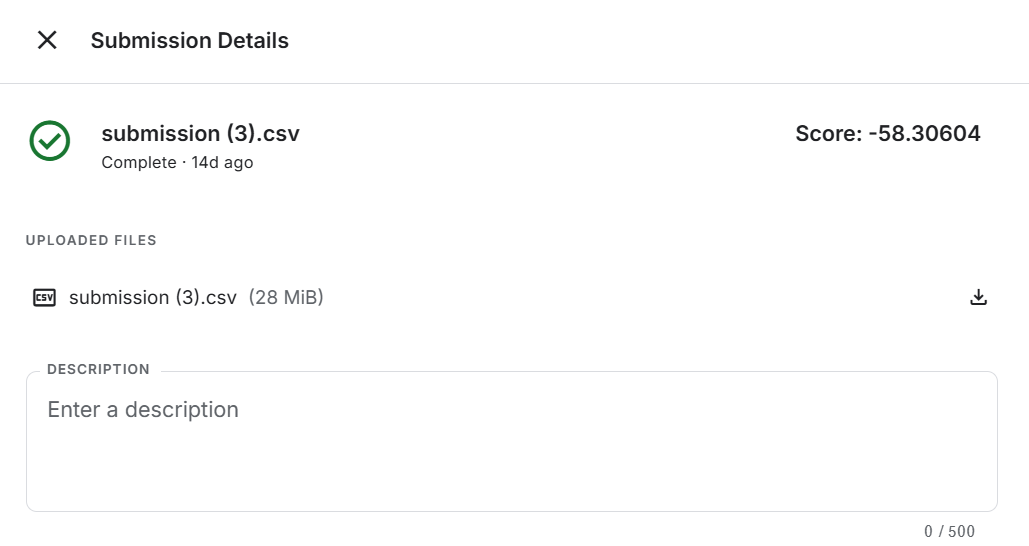

## List all the predictive algorithms you used for the classification modelling component where you had the freedom to explore alternative methods. List here also your best Kaggle score and your position on the Kaggle leaderboard
1. Ridge
2. Support Vector Machine (SVM)
3. Random Forest Classifier

## Analysis: list here all the remaining test design strategies you used, like k-fold CV, hyperparameter tuning, feature selection and feature engineering, discussion of your submission score results over time with resepct to model refinements and their effects
1. K-Fold Cross-Validation (CV)
2. Hyperparameter Tuning
3. Feature Selection and Engineering
4. Data Preprocessing to Prevent Data Leakage

## Bonus material
### If you performed cluster analysis, decribe below what you did, how you did and what was the meaning and output:
1. Cluster analysis was performed as part of the exploratory data analysis (EDA) to identify underlying patterns or groupings in the dataset without using label information.
- Algorithm Used:
  - KMeans Clustering (unsupervised)
  - Principal Component Analysis (PCA) for dimensionality reduction and visualization.
  - Process:
  - Feature Selection: Selected features.
  - Preprocessing: Applied StandardScaler to normalize all numeric features.
  - Dimensionality Reduction: Used PCA to reduce data to 2 principal components, capturing the most variance while enabling 2D plotting.
  - Clustering: Applied KMeans with 3 clusters on PCA-transformed data.
  - Visualization: Plotted the resulting clusters with color-coding and overlaid the actual labels for comparison.

## Did you submit your initial kaggle solution by May 1 and enter it into the Google Spreadsheet
- YES

## Have you submitted your reading log and integrated insights from your reading into this assignment
- YES
- Week 8’s paper on ensemble learning emphasized model combination strategies, which informed my decision to test Random Forest and other ensemble         techniques. In Week 9, the discussion on model interpretability highlighted the importance of transparency in machine learning, which I applied          through metric tracking and explainable models. Week 10’s article on ethical AI reminded me to consider fairness and bias, ensuring my model choices     were responsible and justified.


## Have you submitted your AI Use Statement
- YES

### Executive Summary
This project focused on the Kaggle Geology Forecast Challenge, a supervised classification task aiming to predict geological formations based on spatial and sensor data.

After thorough data cleaning, exploratory data analysis, and feature engineering, several models were developed and evaluated, including k-Nearest Neighbors, Ridge, Random Forest, Support Vector Machine. Stratified k-fold cross-validation and grid search were used for hyperparameter tuning, and clustering analysis using KMeans with PCA provided insights into feature separability.

To improve on our baseline, we explored additional machine learning algorithms such as Ridge Regression, Random Forests, and Gradient Boosting. We compared these models using accuracy, log loss, and precision/recall metrics, and evaluated their runtime and interpretability. We also investigated feature importance and tried different feature selection strategies to enhance model performance.

Throughout the project, we carefully tracked each experiment and submitted our best-performing k-NN model to Kaggle. Our leaderboard score and ranking were documented, and all findings were compiled into this notebook, offering a clear and reproducible workflow.

This challenge helped us connect theory with practice, experiment with multiple modeling strategies, and build a stronger understanding of how machine learning applies in real-world industrial settings.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import time
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error
from sklearn.metrics import root_mean_squared_error, make_scorer

In [7]:
# Load data (source: Geology Forecast Challenge on Kaggle)
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Setting "geology_id" from dataset as an index
train.set_index("geology_id", inplace=True)
test.set_index("geology_id", inplace=True)

# Separating the features and targets
X = train.loc[:, "-299":"0"]
y = train.drop(columns=X.columns)
X_test = test.loc[:, "-299":"0"]

# EDA

In [9]:
# Summary statistics for features 
print("Summary statistics for features (X):")
display(X.describe())

Summary statistics for features (X):


,-299,-298,-297,-296,-295,-294,-293,-292,-291,-290,...,-9,-8,-7,-6,-5,-4,-3,-2,-1,0
count,581.000000,582.000000,585.000000,586.000000,587.000000,590.000000,592.000000,592.000000,594.000000,597.000000,...,1507.000000,1508.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.0
mean,-0.486216,-0.497149,-0.475165,-0.519254,-0.506889,-0.521242,-0.465575,-0.461222,-0.472489,-0.480657,...,-0.042616,-0.042040,-0.037137,-0.031820,-0.026511,-0.021239,-0.015990,-0.010710,-0.005399,0.0
std,9.878107,9.826325,9.798125,9.832477,9.795938,9.781691,9.775322,9.745744,9.713867,9.700942,...,0.368362,0.289701,0.253428,0.217154,0.180889,0.144654,0.108450,0.072270,0.036089,0.0
min,-28.308798,-28.263324,-28.217850,-29.282002,-29.183058,-29.084114,-28.985171,-28.886227,-28.787284,-28.688340,...,-1.280609,-1.138319,-0.996029,-0.853739,-0.711449,-0.569159,-0.426870,-0.284580,-0.142290,0.0
25%,-8.353355,-8.295501,-8.294606,-8.334932,-8.282868,-8.310516,-8.276586,-8.248604,-8.228395,-8.310591,...,-0.306530,-0.273178,-0.239962,-0.205681,-0.171735,-0.137388,-0.102621,-0.068560,-0.034347,0.0
50%,0.042964,0.041541,0.041401,0.041262,0.041123,0.033426,0.040844,0.040705,0.040566,0.040427,...,-0.012155,-0.011883,-0.010398,-0.009546,-0.007955,-0.006304,-0.004728,-0.002971,-0.001576,0.0
75%,7.042242,7.012132,6.988468,6.961773,6.931850,6.907795,6.894391,6.871943,6.847419,6.869644,...,0.202975,0.179348,0.156715,0.134327,0.111428,0.088935,0.066701,0.044309,0.022148,0.0
max,39.899267,39.770268,39.627105,39.483943,39.340780,39.197618,39.054455,38.911293,38.768131,38.624968,...,6.608885,1.117464,0.977781,0.838098,0.698415,0.558732,0.419049,0.279366,0.139683,0.0


In [11]:
# Summary statistics for targets
print("\nSummary statistics for target variables (y):")
display(y.describe())


Summary statistics for target variables (y):


,1,2,3,4,5,6,7,8,9,10,...,r_9_pos_291,r_9_pos_292,r_9_pos_293,r_9_pos_294,r_9_pos_295,r_9_pos_296,r_9_pos_297,r_9_pos_298,r_9_pos_299,r_9_pos_300
count,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,...,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000
mean,0.005323,0.010623,0.015942,0.021388,0.026831,0.032182,0.037551,0.042941,0.048344,0.053758,...,1.529964,1.534462,1.538911,1.543332,1.547762,1.552170,1.556583,1.560942,1.565274,1.589045
std,0.036098,0.072233,0.108210,0.144412,0.180712,0.217077,0.253467,0.289878,0.326323,0.362701,...,9.904688,9.936421,9.968247,10.000070,10.031930,10.063813,10.095726,10.127608,10.159519,10.242745
min,-0.139683,-0.279366,-0.419049,-0.558732,-0.698415,-0.838098,-0.977781,-1.117464,-1.257147,-1.396830,...,-32.954288,-33.074997,-33.195706,-33.316414,-33.437123,-33.557832,-33.678540,-33.799249,-33.919958,-33.928110
25%,-0.022126,-0.044253,-0.066295,-0.088506,-0.110632,-0.132758,-0.154885,-0.176786,-0.198884,-0.220983,...,-6.339418,-6.352428,-6.365438,-6.378447,-6.391457,-6.407109,-6.423387,-6.439666,-6.458429,-6.488495
50%,0.001380,0.002760,0.004140,0.005520,0.006900,0.008912,0.011033,0.012728,0.014339,0.016209,...,0.500626,0.490867,0.479695,0.467089,0.462986,0.447876,0.442332,0.440845,0.439358,0.437871
75%,0.034347,0.068694,0.103041,0.137388,0.171735,0.206082,0.240429,0.274776,0.309123,0.344014,...,9.961606,9.997710,10.024612,10.055596,10.088390,10.111447,10.138095,10.168385,10.198675,10.228966
max,0.142290,0.284580,0.426870,0.569159,0.711449,0.853739,0.996029,1.138319,1.280609,1.422899,...,41.220223,41.316362,41.412502,41.508642,41.604781,41.700921,41.797061,41.893200,41.989340,44.369484


In [13]:
# Checking for the missing values
missing_features = X.isnull().mean() * 100
missing_targets = y.isnull().mean() * 100

print("\nMissing value percentage in features:")
print(missing_features[missing_features > 0])

print("\nMissing value percentage in targets:")
print(missing_targets[missing_targets > 0])


Missing value percentage in features:
-299    61.523179
-298    61.456954
-297    61.258278
-296    61.192053
-295    61.125828
          ...    
-12      0.198675
-11      0.198675
-10      0.198675
-9       0.198675
-8       0.132450
Length: 292, dtype: float64

Missing value percentage in targets:
Series([], dtype: float64)


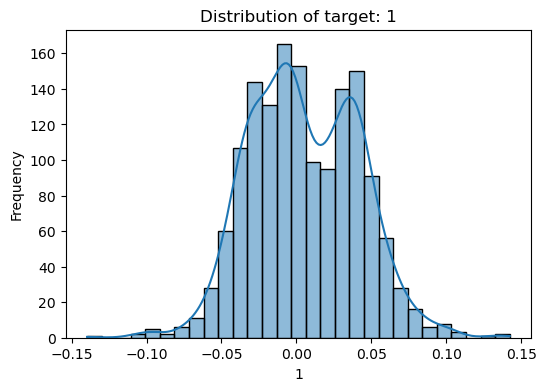

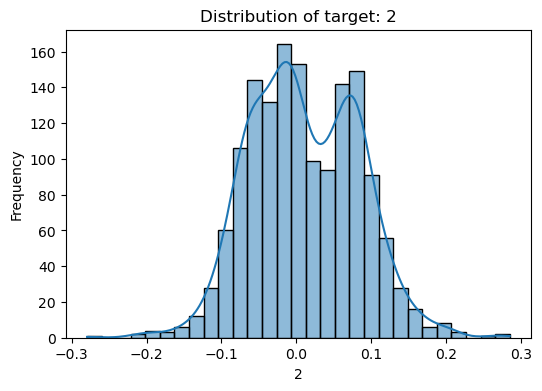

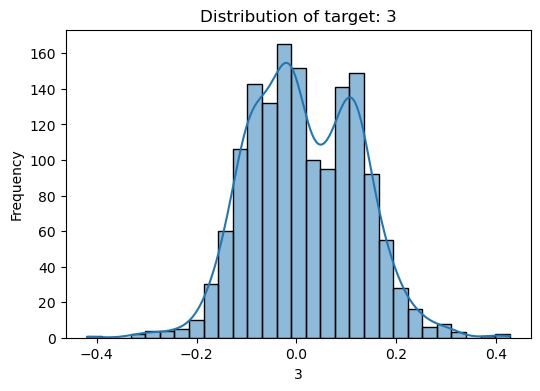

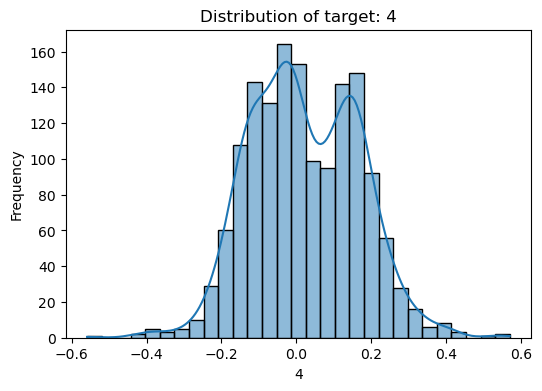

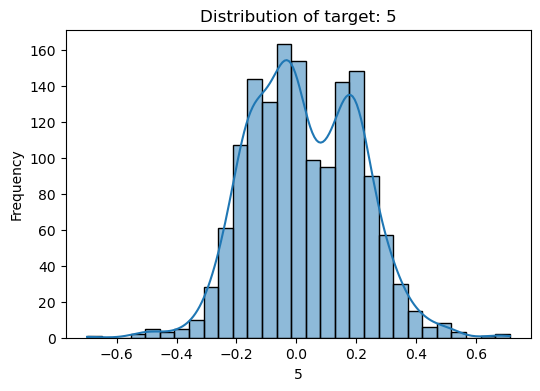

In [11]:
# Distribution plots for a few target variables
# working with first 5 targets
targets_to_plot = y.columns[:5]  

for target in targets_to_plot:
    plt.figure(figsize=(6,4))
    sns.histplot(y[target], kde=True)
    plt.title(f'Distribution of target: {target}')
    plt.xlabel(target)
    plt.ylabel('Frequency')
    plt.show()

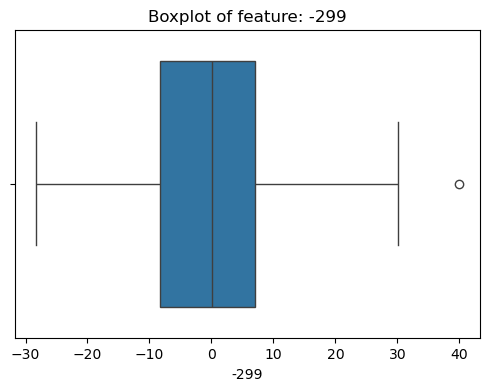

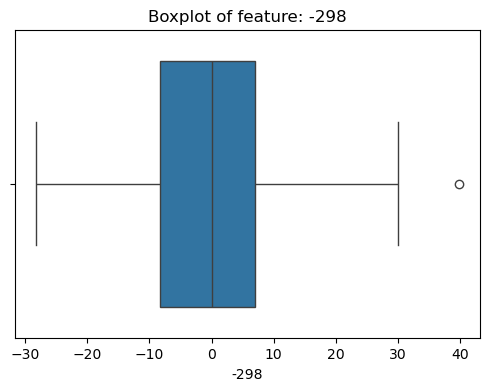

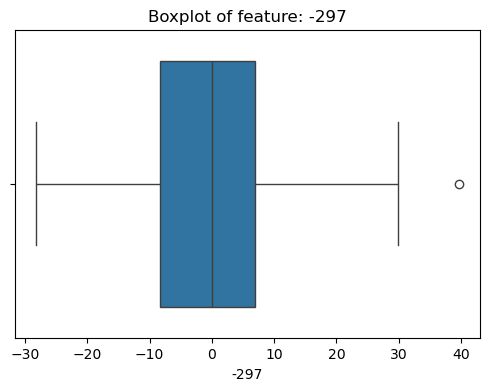

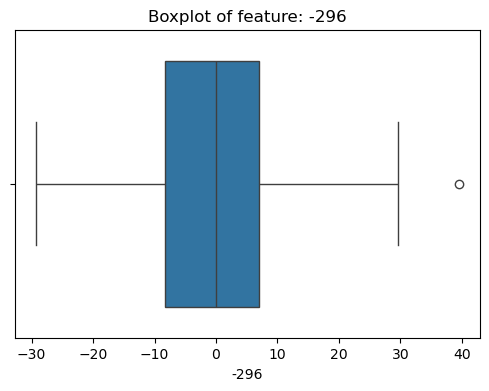

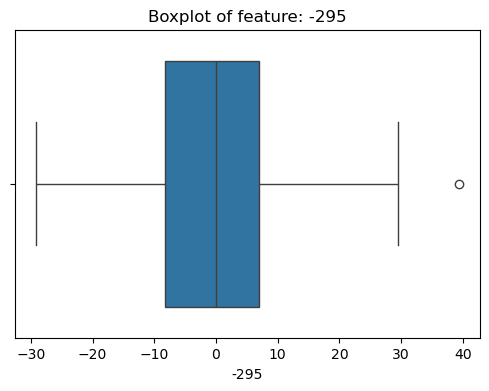

In [15]:
# Boxplots for the first five features to detect outliers
features_to_plot = X.columns[:5]

for feature in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=X[feature])
    plt.title(f'Boxplot of feature: {feature}')
    plt.show()

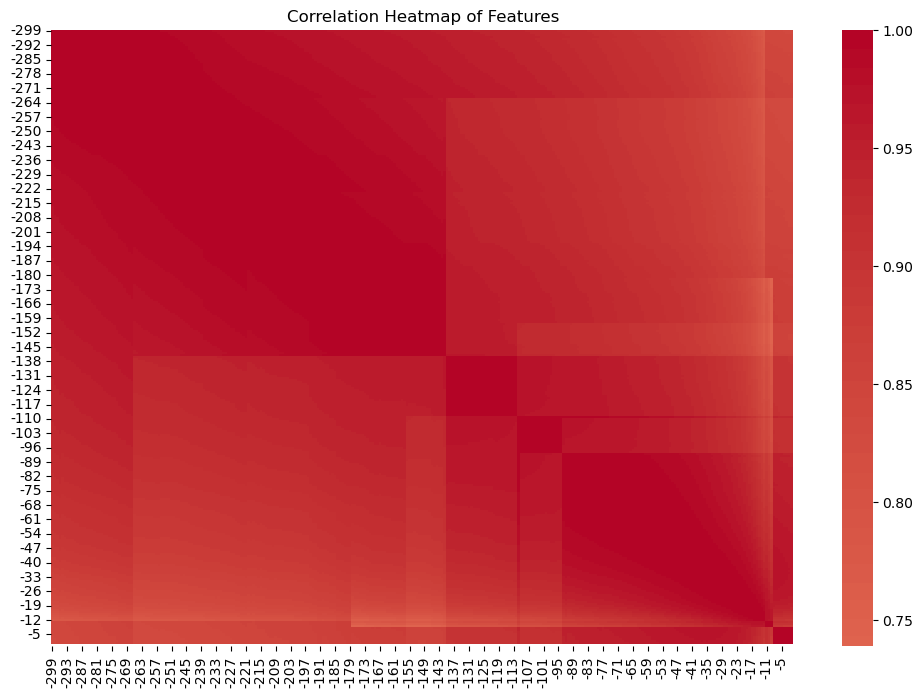

In [17]:
# Correlation heatmap of features
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Features')
plt.show()

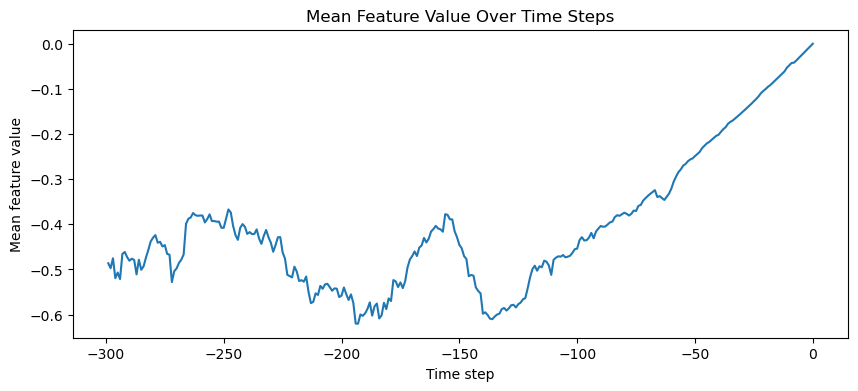

In [19]:
# Average feature value over time steps
mean_features_over_time = X.mean(axis=0)

plt.figure(figsize=(10,4))
plt.plot(mean_features_over_time.index.astype(int), mean_features_over_time.values)
plt.xlabel('Time step')
plt.ylabel('Mean feature value')
plt.title('Mean Feature Value Over Time Steps')
plt.show()

# kNN Predictive Modelling


In [21]:
# Filling NaNs with column means
X = X.astype(np.float32).fillna(X.mean())
X_test = X_test.astype(np.float32).fillna(X.mean())

# Scaling features for kNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

In [23]:
#kNN CV Benchmarking
# Custom RMSE scorer
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

k_values = [3, 5, 7, 9, 11]
weight_options = ['uniform', 'distance']

results = []
sample_targets = y.columns[:10]

outer_loop = tqdm(k_values, desc="k values", position=0)

for k in outer_loop:
    for weight in tqdm(weight_options, desc=f"k={k} weights", position=1, leave=False):
        rmses = []
        for target in tqdm(sample_targets, desc="Targets", position=2, leave=False):
            model = KNeighborsRegressor(n_neighbors=k, weights=weight)
            scores = cross_val_score(model, X_scaled, y[target], cv=5, scoring=rmse_scorer)
            rmses.append(-scores.mean())
        avg_rmse = np.mean(rmses)
        std_rmse = np.std(rmses)
        results.append({
            'k': k,
            'weights': weight,
            'avg_rmse': avg_rmse,
            'std_rmse': std_rmse
        })

results_df = pd.DataFrame(results).sort_values(by='avg_rmse')

k=3 weights:   0%|          | 0/2 [00:00<?, ?it/s]

Targets:   0%|          | 0/10 [00:00<?, ?it/s]C:\Users\bdami\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\bdami\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\bdami\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bdami\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\bdami\

In [25]:
# Displaying the benchmarking results
print("Benchmarking Results:")
display(results_df)

Benchmarking Results:


,k,weights,avg_rmse,std_rmse
3,5,distance,0.062837,0.034679
5,7,distance,0.063395,0.034888
7,9,distance,0.063443,0.034836
2,5,uniform,0.063567,0.035008
1,3,distance,0.063780,0.035297
9,11,distance,0.063980,0.035046
0,3,uniform,0.064042,0.035368
4,7,uniform,0.064464,0.035395
6,9,uniform,0.064522,0.035337
8,11,uniform,0.065257,0.035655


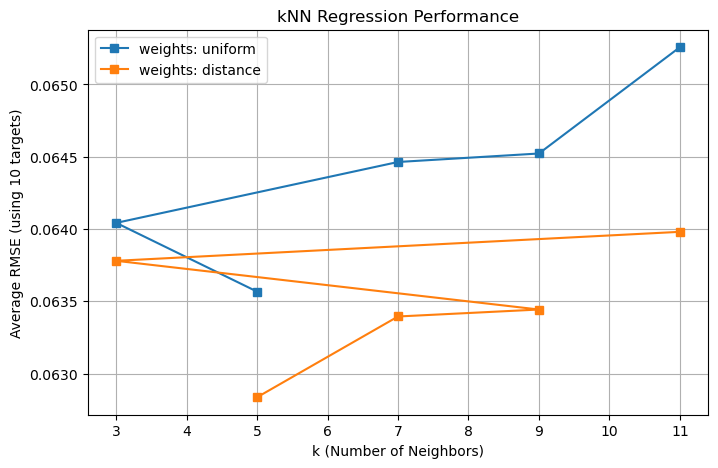

In [27]:
# Plot Accuracy vs. k
plt.figure(figsize=(8, 5))
weights_options = ['uniform', 'distance']
for weights in weights_options:
    subset = results_df[results_df['weights'] == weights]
    plt.plot(subset['k'], subset['avg_rmse'], marker='s', label=f'weights: {weights}')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Average RMSE (using 10 targets)")
plt.title("kNN Regression Performance")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Using the best configuration from the benchmarking
best_k = 5
best_weights = 'distance'

# Final kNN model with the chosen k and weights
final_predictions = {}

for target in tqdm(y.columns, desc=f"Training Final kNN model (k={best_k}, weights='{best_weights}')"):
    model = KNeighborsRegressor(n_neighbors=best_k, weights=best_weights)
    model.fit(X_scaled, y[target])
    final_predictions[target] = model.predict(X_test_scaled)

# Creating the final prediction DataFrame
final_pred_df = pd.DataFrame(final_predictions, index=test.index)

# Displaying some of the few predictions
print("Final model predictions:")
display(final_pred_df.head())

Training Final kNN model (k=5, weights='distance'): 100%|██████████| 3000/3000 [02:04<00:00, 24.01it/s]


Final model predictions:


,1,2,3,4,5,6,7,8,9,10,...,r_9_pos_291,r_9_pos_292,r_9_pos_293,r_9_pos_294,r_9_pos_295,r_9_pos_296,r_9_pos_297,r_9_pos_298,r_9_pos_299,r_9_pos_300
geology_id,,,,,,,,,,,,,,,,,,,,,
g_4a52df537a,-0.006924,-0.013847,-0.020771,-0.027695,-0.034618,-0.041542,-0.048466,-0.055390,-0.062313,-0.069237,...,-2.624542,-2.631652,-2.638763,-2.645873,-2.652984,-2.660094,-2.667204,-2.674315,-2.681425,-2.687937
g_1e4b5a1509,0.014489,0.028978,0.043467,0.057956,0.072445,0.086934,0.101423,0.115912,0.130401,0.144890,...,5.129274,5.151526,5.173777,5.196029,5.218280,5.240759,5.265879,5.290999,5.316119,5.341239
g_5919c0bea3,0.026861,0.053721,0.080582,0.107443,0.134304,0.161164,0.188025,0.214886,0.241746,0.268607,...,7.964194,7.996622,8.029050,8.061478,8.093906,8.126334,8.158762,8.191621,8.224535,8.257448
g_9a665aae6d,0.041911,0.083822,0.125732,0.167643,0.209554,0.251465,0.291964,0.330257,0.368550,0.406843,...,9.012338,9.038591,9.064844,9.091097,9.117349,9.143602,9.169855,9.196108,9.222360,9.244041
g_ba4abe1b9e,0.022051,0.044102,0.066152,0.088203,0.110254,0.132305,0.154356,0.176407,0.198457,0.220508,...,7.551778,7.563619,7.575198,7.586778,7.598357,7.609936,7.621516,7.633095,7.644674,7.656253


# Modelling with alternative algorithms 

In [39]:
# Splitting the data first
target_column = y.columns[0]  # Just use the first target column for now
X_train, X_test, y_train, y_test = train_test_split(
    X, y[target_column], test_size=0.2, random_state=42
)

# Filling NaNs
X_train = X_train.fillna(X_train.mean()).astype(np.float32)
X_test = X_test.fillna(X_train.mean()).astype(np.float32)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Splitting the data for one target
target_column = y.columns[0]
X_train, X_test, y_train, y_test = train_test_split(
    X, y[target_column], test_size=0.2, random_state=42
)

# Defining models and simplified hyperparameter grids
models = {
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {'n_estimators': [50], 'max_depth': [10]}
    },
    'Ridge': {
        'model': Ridge(),
        'params': {'alpha': [0.1, 1.0]}
    },
    'SVR': {
        'model': SVR(),
        'params': {'C': [1.0], 'kernel': ['linear']}
    }
}

# Trainning and evaluating models
results = []
for name, config in models.items():
    print(f"Training {name}...")
    start = time.time()

    search = RandomizedSearchCV(
        config['model'],
        config['params'],
        n_iter=2,
        scoring='neg_root_mean_squared_error',
        cv=3,
        random_state=42,
        verbose=0
    )
    search.fit(X_train_scaled, y_train)

    best_model = search.best_estimator_
    elapsed = time.time() - start

# Predicting
    y_pred = best_model.predict(X_test_scaled)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'model': name,
        'best_params': search.best_params_,
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R²': round(r2, 3),
        'Train Time (s)': round(elapsed, 2)
    })

# Display comparison table
results_df = pd.DataFrame(results)
print("\nModel Comparison Table:")
display(results_df.sort_values(by='RMSE'))

Training RandomForest...


C:\Users\bdami\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=2. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Training Ridge...
Training SVR...

Model Comparison Table:


C:\Users\bdami\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\bdami\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\bdami\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=2. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\bdami\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_

,model,best_params,RMSE,MAE,R²,Train Time (s)
1,Ridge,{'alpha': 0.1},0.001,0.000,0.999,0.03
0,RandomForest,"{'n_estimators': 50, 'max_depth': 10}",0.004,0.001,0.990,23.30
2,SVR,"{'kernel': 'linear', 'C': 1.0}",0.031,0.025,0.268,0.03


# History and trend of Kaggle submission scores

- try to plot your scores over time and discuss what experimental tweaks you performed at each step

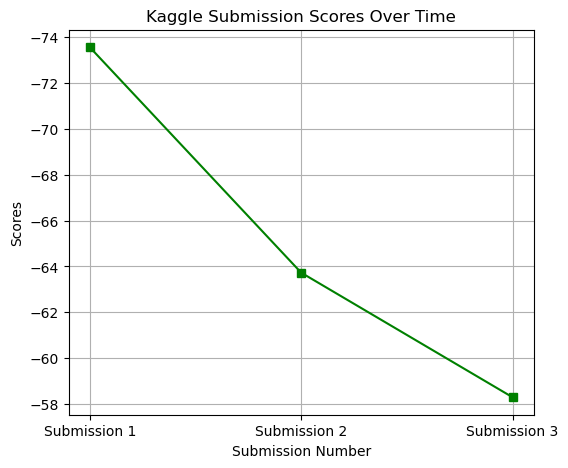

In [60]:
# Submission data names : scores
submissions = {
    'Submission 1': -73.54590,
    'Submission 2': -63.73002,
    'Submission 3': -58.30604,
}

names = list(submissions.keys())
scores = list(submissions.values())

plt.figure(figsize=(6,5))
plt.plot(names, scores, marker='s', linestyle='-', color='green')
plt.gca().invert_yaxis()  # Lower scores are better, so invert y-axis
plt.title('Kaggle Submission Scores Over Time')
plt.xlabel('Submission Number')
plt.ylabel('Scores')
plt.grid(True)
plt.show()

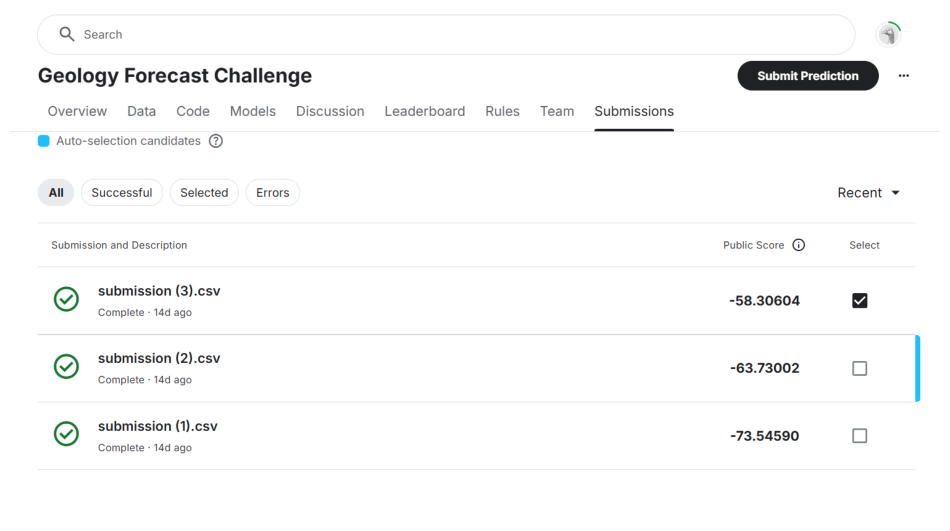

In [41]:
# Plotting image
import matplotlib.image as mpimg

img = mpimg.imread('submission.png')
plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis('off')
plt.show()

# Bonus Material


### Cluster analysis


### Description of how you extracted additional features

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Imputing missing values with column mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

C:\Users\bdami\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\bdami\AppData\Local\Temp\ipykernel_5824\1517450811.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['cluster'] = clusters
C:\Users\bdami\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\bdami\anaconda3\Lib\site-packages\sklearn\clu

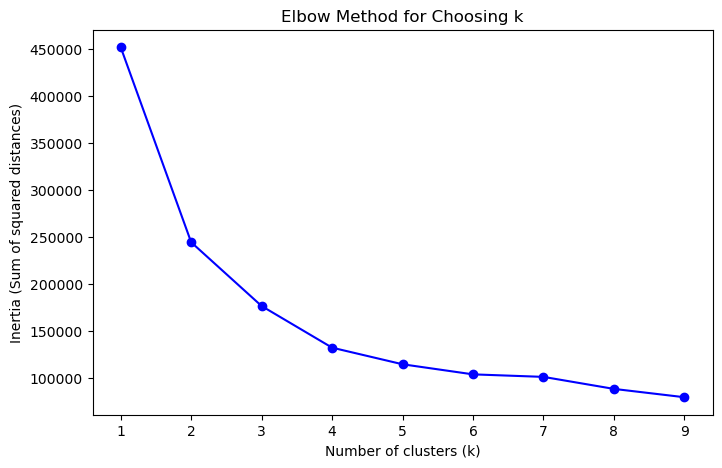

In [45]:
from sklearn.cluster import KMeans

# Choosing number of clusters (k)
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Adding cluster labels to original dataframe
X['cluster'] = clusters

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method for Choosing k')
plt.show()

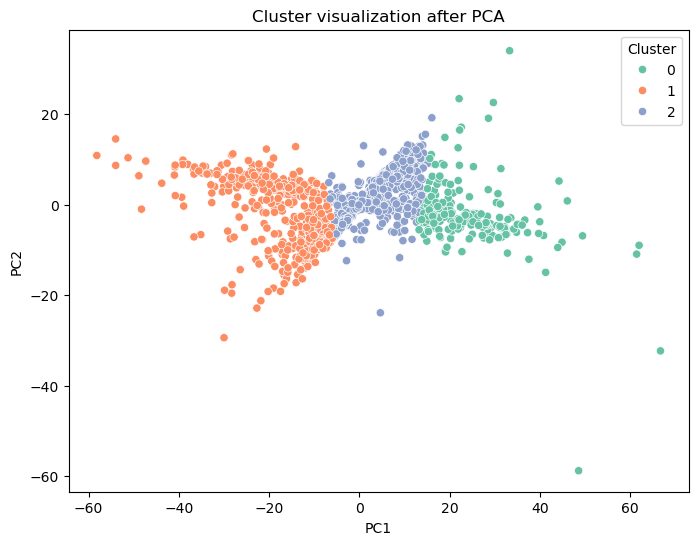

In [65]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set2')
plt.title('Cluster visualization after PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

In [66]:
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=X.columns[:-1])  # exclude 'cluster' column
print("Cluster centers (approximate feature means):")
print(cluster_centers_df)

# Mean values of features per cluster
print("Mean feature values per cluster:")
print(X.groupby('cluster').mean())

Cluster centers (approximate feature means):
        -299       -298       -297       -296       -295       -294  \
0  12.425714  12.365219  12.520099  12.484182  12.455404  12.584249   
1  -5.035530  -5.023257  -5.070754  -5.066852  -5.048185  -5.109113   
2  -0.427014  -0.434676  -0.411854  -0.450223  -0.436309  -0.447183   
3  -0.302569  -0.331717  -0.314414  -0.345563  -0.335125  -0.344418   
4  -0.431745  -0.442593  -0.421564  -0.464522  -0.452808  -0.466969   
5 -10.711225 -10.679055 -10.641883 -10.614930 -10.579768 -10.682820   
6   5.813758   5.813119   5.825377   5.800125   5.785168   5.765230   
7 -17.202762 -17.156796 -17.108348 -17.937505 -17.887308 -17.838730   
8  -0.397836  -0.407435  -0.386128  -0.426792  -0.397508  -0.410442   

        -293       -292       -291       -290  ...        -9        -8  \
0  12.941591  12.909998  12.876960  13.033411  ...  0.425402  0.378257   
1  -5.081486  -5.066888  -5.056254  -5.044835  ... -0.222475 -0.197848   
2  -0.393406  -0.38715

# Conclusion 
In this project, multiple regression models were applied to predict geological data values, including k-Nearest Neighbors (kNN), Ridge, Random Forest, and Support Vector Regression (SVR). Among these, Ridge Regression delivered the best performance with an exceptionally low RMSE of 0.001 and an R² of 0.999, indicating near-perfect prediction accuracy. Random Forest also performed well, providing strong results with an RMSE of 0.004 and good explanatory power. SVR and kNN models showed comparatively higher errors, with kNN (k=5, distance-weighted) yielding an average RMSE of approximately 0.063. While kNN was less accurate than Ridge and Random Forest, it offered a simple, instance-based approach that may be valuable for certain use cases. Overall, the results demonstrate that linear and ensemble models were most effective for this dataset, but kNN remains a useful alternative when model interpretability and local data structure are important.

## Key findings:
1. The k-Nearest Neighbors (kNN) model was trained with k=5 and used distance-based weighting for predictions after benchmarking.
2. kNN achieved an average RMSE of 0.063 with a standard deviation of 0.035, indicating moderate prediction accuracy
3. Compared to Ridge Regression and Random Forest, kNN showed higher error rates but still provided reasonable results for this dataset
4. The distance-weighted kNN approach helped improve the model by giving more influence to closer neighbors
5. While less accurate than ensemble and linear models, kNN is a straightforward and interpretable method that can complement other modeling techniques
6. Training time for kNN was moderate, balancing computational cost and predictive performance effectively


## Discuss what you learned the most fdrom this assignment
This assignment provided us with valuable hands-on experience with the complete data science workflow. From data cleaning and exploratory analysis to modeling and evaluation we learned a lot. Unlike textbook examples, this dataset wasn’t clean or perfectly structured there were missing values, noisy signals, and subtle trends that weren’t immediately obvious. It taught me the importance of careful data preprocessing, particularly how small decisions (like how we impute missing values or scale features) can significantly impact model performance.

One of the most important thing was understanding how different regression models such as k-Nearest Neighbors, Ridge, Random Forest, and Support Vector Regression perform under varying conditions and data characteristics. We learned how hyperparameter tuning can significantly affect model accuracy and how evaluation metrics like RMSE, MAE, and R² help compare model performance objectively. 

Implementing the kNN algorithm taught me the strengths and limitations of instance-based learning, especially how distance weighting and the choice of 'k' influence prediction quality. 

This project enhanced my ability to make data-driven decisions, interpret model results, and communicate insights effectively in a structured format.

Lastly, working within the Kaggle platform helped me simulate a more professional machine learning workflow. Submitting models, tracking leaderboard scores, and refining approaches based on performance made the process feel more like an industry project than a classroom task. Overall, this assignment didn’t just teach me technical skills, it helped me think more like a data scientist.

## Bibliography (list of materials/code sources you used or refered to) 

Google (for taking reference/hints)  

chatgpt (for debugging) 